In [1]:
import sys
sys.path.append("/home/jiahuang/test-code-hazel/")
import gen_fxns
from plot_pca import plot_pca_loadings
import h5py
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import scipy as sp
import sklearn
from datetime import date
import pandas as pd 
from datetime import timedelta
from scipy.stats import zscore
import seaborn as sns 
import pickle 
import os 
from datetime import datetime
from scipy.stats import zscore
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [5]:
feat_df_roi_temp=pd.read_csv("/home/jiahuang/test-code-hazel/ridgeregression_psdfeat_and_aperiodic_df.csv")
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')
feat_df_roi = feat_df_roi_temp.merge(behavior_table,on=['ptID','trial_idx'])
feat_df_roi

,ptID,trial_idx,alpha__L ACC_corrected_z,alpha__L AINS_corrected_z,alpha__L Caudate_corrected_z,alpha__L IC_corrected_z,alpha__L MCC_corrected_z,alpha__L OFC_corrected_z,alpha__L PINS_corrected_z,alpha__L THAL_corrected_z,...,nrs_z,vasp_z,somatic_z,unpleasantness_z,affective_z,vasd_r_z,pca_sensory_PC1,pca_affective_PC1,new_affective_PC1,new_sensory_PC1
0,RCS02,32,NaN,-1.971147,NaN,-0.464212,-0.070879,NaN,-0.965779,NaN,...,-1.572153,-2.331655,-1.537004,-0.944105,-0.653720,0.857070,-3.148555,-0.184285,-1.129834,-2.735555
1,RCS02,33,NaN,-2.154493,NaN,0.581104,0.242829,NaN,-2.163424,NaN,...,0.060467,-0.731112,-1.256605,0.075528,-0.653720,-0.353790,-1.063422,-0.692122,-0.408843,-1.405528
2,RCS02,34,NaN,-0.324388,NaN,0.091024,-0.500044,NaN,-2.175785,NaN,...,0.060467,-0.159490,-0.976205,0.624562,-0.065372,0.722530,-0.576758,0.541736,0.395407,-0.803058
3,RCS02,35,NaN,0.237283,NaN,0.492406,0.381685,NaN,-1.133231,NaN,...,0.060467,0.183484,-0.695806,-0.630372,5.229764,3.413329,-0.225095,5.890015,3.252261,-0.362266
4,RCS02,36,NaN,0.103299,NaN,-0.120362,-0.142492,NaN,-0.815080,NaN,...,0.876777,-0.159490,0.986590,-0.630372,-1.242069,1.395229,0.962826,-0.222151,-1.324016,0.584849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,RCS09,145,NaN,-0.814665,0.414892,0.064666,0.290548,0.221440,-2.382298,0.243446,...,0.095929,0.044711,-0.084711,0.050901,NaN,NaN,0.033547,0.050901,0.050901,-0.028284
661,RCS09,146,NaN,0.527906,0.544040,0.005088,-0.076061,0.190942,0.563577,-0.235256,...,0.095929,0.086111,-0.084711,0.050901,NaN,NaN,0.057536,0.050901,0.050901,0.000990
662,RCS09,147,NaN,0.898246,0.170932,0.595023,0.453848,0.186772,0.720471,0.739283,...,-0.383718,-0.493481,-1.017309,-1.034102,NaN,NaN,-1.089186,-1.034102,-1.034102,-1.068290
663,RCS09,148,NaN,0.480710,0.387198,0.360339,0.009012,0.444919,0.778983,0.646724,...,-0.863365,-0.700478,-1.133884,-1.114473,NaN,NaN,-1.555070,-1.114473,-1.114473,-1.297090


In [6]:
# coverage = feat_df_roi[['ptID']+[c for c in feat_df_roi.columns if c.endswith('_corrected_z')]].groupby("ptID").apply(lambda g: g.iloc[:,1:].notna().any())
# coverage.loc['pct_true'] = coverage.mean() * 100
coverage = feat_df_roi[['ptID']+[c for c in feat_df_roi.columns if c.endswith('t_z')]].groupby("ptID").apply(lambda g: g.iloc[:,1:].notna().any())

coverage_frac = coverage.mean()
keep_rois = coverage_frac[coverage_frac >= 0.625].index.tolist()
# rois_only = sorted(set(
#     c.split('__', 1)[1].replace('_corrected_z', '').replace('_raw_z', '')
#     for c in keep_rois
# ))
rois_only = sorted(set(
    c.replace('_exponent_z', '').replace('_offset_z', '')
    for c in keep_rois
))

/tmp/ipykernel_2657027/611030978.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coverage = feat_df_roi[['ptID']+[c for c in feat_df_roi.columns if c.endswith('t_z')]].groupby("ptID").apply(lambda g: g.iloc[:,1:].notna().any())


In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr
keep_cols_final = [c for c in feat_df_roi.columns if any(roi in c for roi in rois_only)]
feat_cols = [c for c in keep_cols_final if c.endswith('t_z')]

X_df = feat_df_roi[feat_cols].copy()
X = X_df.values

# y_aff  = feat_df_roi['aff_score'].values
# y_sens = feat_df_roi['sens_score'].values
y_nrs  = feat_df_roi['nrs_z'].values

alphas_grid = [1, 2, 50, 75, 100, 200]
y_bins_nrs  = pd.qcut(y_nrs,  q=3, labels=False, duplicates='drop')
# y_bins_aff  = pd.qcut(y_aff,  q=3, labels=False, duplicates='drop')
# y_bins_sens = pd.qcut(y_sens, q=3, labels=False, duplicates='drop')
def run_nested_cv(X, y, y_bins, alphas_grid, feat_cols, n_splits=10, random_state=42):
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('ridge', RidgeCV(fit_intercept=False, alphas=alphas_grid))
    ])

    y_pred = np.zeros_like(y, dtype=float)
    fold_coefs = []
    fold_alphas = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y_bins)):
        pipe.fit(X[train_idx], y[train_idx])
        y_pred[test_idx] = pipe.predict(X[test_idx])

        fold_coefs.append(pipe.named_steps['ridge'].coef_)
        fold_alphas.append(pipe.named_steps['ridge'].alpha_)

    fold_coefs = np.array(fold_coefs)  # shape: (n_splits, n_features)

    coef_stability_df = pd.DataFrame({
        'feature': feat_cols,
        'mean_coef': fold_coefs.mean(axis=0),
        'std_coef': fold_coefs.std(axis=0),
        'snr': fold_coefs.mean(axis=0) / fold_coefs.std(axis=0),
        'sign_consistency': (np.sign(fold_coefs) == np.sign(fold_coefs.mean(axis=0))).mean(axis=0),
    }).sort_values('snr', key=np.abs, ascending=False)

    return y_pred, fold_coefs, coef_stability_df, fold_alphas

# y_pred_nrs  = run_nested_cv(X, y_nrs,  y_bins_nrs,  alphas_grid)
# y_pred_aff  = run_nested_cv(X, y_aff,  y_bins_aff,  alphas_grid)
# y_pred_sens = run_nested_cv(X, y_sens, y_bins_sens, alphas_grid)

def summarize_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    r, p_r     = pearsonr(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"  R2            = {r2:.3f}")
    print(f"  Pearson r     = {r:.3f}  (p={p_r:.4f})")
    return {'R2': r2, 'pearson_r': r, 'pearson_p': p_r}
y_pred_nrs, fold_coefs_nrs, coef_stability_nrs, fold_alphas_nrs = run_nested_cv(
    X, y_nrs, y_bins_nrs, alphas_grid, feat_cols
)
metrics_nrs  = summarize_metrics(y_nrs,  y_pred_nrs,  'aff_score  (StratifiedKFold)')


display(coef_stability_nrs)
# metrics_aff  = summarize_metrics(y_aff,  y_pred_aff,  'aff_score  (StratifiedKFold)')
# metrics_sens = summarize_metrics(y_sens, y_pred_sens, 'sens_score (StratifiedKFold)')

metrics_df = pd.DataFrame(
    {'nrs': metrics_nrs}
    # {'aff': metrics_aff, 'sens': metrics_sens}
    )
display(metrics_df)
imputer_full = SimpleImputer(strategy='mean').fit(X)
X_full_imputed = imputer_full.transform(X)

full_cv_nrs  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_full_imputed, y_bins_nrs)
# full_cv_aff  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_full_imputed, y_bins_aff)
# full_cv_sens = StratifiedKFold(n_splits=10, shuffle=True, random_state=42).split(X_full_imputed, y_bins_sens)

final_ridge_nrs = RidgeCV(fit_intercept=False,alphas=alphas_grid, cv=list(full_cv_nrs)).fit(X_full_imputed, y_nrs)
# final_ridge_aff  = RidgeCV(fit_intercept=False,alphas=alphas_grid, cv=list(full_cv_aff)).fit(X_full_imputed, y_aff)
# final_ridge_sens = RidgeCV(fit_intercept=False,alphas=alphas_grid, cv=list(full_cv_sens)).fit(X_full_imputed, y_sens)

# print(f"final alpha_aff: {final_ridge_aff.alpha_}, final alpha_sens: {final_ridge_sens.alpha_}")

coef_df = pd.DataFrame({
    'coef_nrs': final_ridge_nrs.coef_
    # 'coef_aff':  final_ridge_aff.coef_,
    # 'coef_sens': final_ridge_sens.coef_,
}, index=X_df.columns)

coef_df

--- aff_score  (StratifiedKFold) ---
  R2            = 0.020
  Pearson r     = 0.180  (p=0.0000)


,feature,mean_coef,std_coef,snr,sign_consistency
10,R IC_exponent_z,-0.091084,0.031089,-2.929738,1.0
12,R THAL_exponent_z,0.207469,0.071379,2.906576,1.0
26,R MCC_offset_z,0.152751,0.062017,2.463031,1.0
13,R dlPFC_exponent_z,0.089421,0.039404,2.269341,1.0
9,R Caudate_exponent_z,0.100197,0.044530,2.250121,1.0
16,L Caudate_offset_z,-0.284153,0.133535,-2.127923,1.0
15,L AINS_offset_z,-0.102656,0.048268,-2.126796,1.0
17,L IC_offset_z,0.150549,0.076937,1.956766,1.0
6,L dlPFC_exponent_z,0.104540,0.060187,1.736924,1.0
18,L MCC_offset_z,0.119769,0.069001,1.735751,1.0


,nrs
R2,0.020039
pearson_r,0.180033
pearson_p,0.000003


,coef_nrs
L AINS_exponent_z,-0.214384
L Caudate_exponent_z,0.151468
L IC_exponent_z,-0.044498
L MCC_exponent_z,0.042658
L PINS_exponent_z,0.018028
L THAL_exponent_z,-0.321703
L dlPFC_exponent_z,0.063691
L dmPFC_exponent_z,0.517078
R AINS_exponent_z,0.134931
R Caudate_exponent_z,0.122643


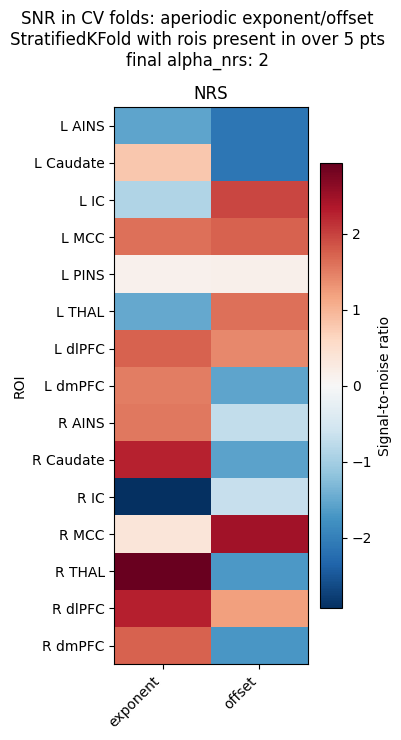

In [14]:
import re

def parse_feat_name_p(name):
    band = name.split('__', 1)[0]
    roi = name.split('__', 1)[1]
    roi = re.sub(r'_(corrected|raw)_z$', '', roi)
    return band, roi

def parse_feat_name_ap(name):
    m = re.match(r'^(.+)_(exponent|offset)_z$', name)
    roi = m.group(1)
    metric = m.group(2)
    return metric, roi
# parsed = coef_df.copy()
# parsed[['band', 'roi']] = parsed.index.to_series().apply(lambda n: pd.Series(parse_feat_name_p(n)))
parsed = coef_stability_nrs[['feature','snr']].copy()
# parsed[['band', 'roi']] = parsed['feature'].apply(lambda n: pd.Series(parse_feat_name_p(n)))
parsed[['metric', 'roi']] = parsed['feature'].apply(lambda n: pd.Series(parse_feat_name_ap(n)))

# bands_order = ['delta', 'theta', 'alpha', 'beta', 'low_gamma', 'high_gamma']
# bands_present = [b for b in bands_order if b in parsed['band'].unique()]
metrics_order = ['exponent', 'offset']
metrics_present = [m for m in metrics_order if m in parsed['metric'].unique()]
rois_present = sorted(parsed['roi'].unique())

mat_nrs = parsed.pivot_table(index='roi', columns='metric', values='snr').reindex(index=rois_present, columns=metrics_present)

max_abs = np.nanmax(np.abs(mat_nrs.values))

fig, ax = plt.subplots(figsize=(4, max(5, 0.5*len(rois_present))))

im = ax.imshow(mat_nrs.values, cmap='RdBu_r', vmin=-max_abs, vmax=max_abs, aspect='auto')
ax.set_xticks(range(len(metrics_present)))
ax.set_xticklabels(metrics_present, rotation=45, ha='right')
ax.set_title('NRS')

ax.set_yticks(range(len(rois_present)))
ax.set_yticklabels(rois_present)
ax.set_ylabel('ROI')

# fig.colorbar(im, ax=ax, label='Signal-to-noise ratio', shrink=0.8)
# fig.suptitle('SNR in CV folds: periodic band power\nStratifiedKFold with rois present in over 5 pts\n'
#              f'final alpha_nrs: {final_ridge_nrs.alpha_}')

fig.colorbar(im, ax=ax, label='Signal-to-noise ratio', shrink=0.8)
fig.suptitle('SNR in CV folds: aperiodic exponent/offset\nStratifiedKFold with rois present in over 5 pts\n'
             f'final alpha_nrs: {final_ridge_nrs.alpha_}')
plt.tight_layout()
plt.show()

In [44]:
# Individual model: Per channel ridge and per channel logistic regression

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

def fit_full_and_bootstrap(X, y, n_components, n_bootstrap=1000, random_state=42):
    feature_names = X.columns
    X_arr, y_arr = X.values, np.asarray(y)
    n_samples = len(X_arr)

    # --- 1. full-sample fit ---
    pipe_full = make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=random_state),
        LogisticRegressionCV(
            penalty="l2", solver="liblinear", Cs=10,
            max_iter=1000, random_state=random_state,
            scoring="roc_auc", cv=3
        )
    )
    pipe_full.fit(X_arr, y_arr)
    pca_full = pipe_full.named_steps["pca"]
    logreg_full = pipe_full.named_steps["logisticregressioncv"]
    beta_feature_full = pca_full.components_.T @ logreg_full.coef_.ravel()
    full_sample_weight = pd.Series(beta_feature_full, index=feature_names, name="full_sample_weight")
    ref = beta_feature_full

    # --- 2. bootstrap resampling ---
    rng = np.random.RandomState(random_state)
    weight_matrix = np.full((n_bootstrap, len(feature_names)), np.nan)
    oob_auc_list = []
    n_flipped = 0
    c_selected = []

    for b in range(n_bootstrap):
        boot_idx = rng.randint(0, n_samples, size=n_samples)
        oob_idx = np.setdiff1d(np.arange(n_samples), np.unique(boot_idx))

        if len(oob_idx) == 0 or len(np.unique(y_arr[oob_idx])) < 2:
            continue
        if len(np.unique(y_arr[boot_idx])) < 2:
            continue

        X_boot, y_boot = X_arr[boot_idx], y_arr[boot_idx]
        X_oob, y_oob = X_arr[oob_idx], y_arr[oob_idx]

        min_class_count = pd.Series(y_boot).value_counts().min()
        if min_class_count < 3:
            continue

        pipe = make_pipeline(
            StandardScaler(),
            PCA(n_components=n_components, random_state=random_state),
            LogisticRegressionCV(
                penalty="l2", solver="liblinear", Cs=10,
                max_iter=1000, random_state=random_state,
                scoring="roc_auc", cv=3
            )
        )
        pipe.fit(X_boot, y_boot)

        y_oob_proba = pipe.predict_proba(X_oob)[:, 1]
        oob_auc_list.append(roc_auc_score(y_oob, y_oob_proba))

        pca = pipe.named_steps["pca"]
        logreg = pipe.named_steps["logisticregressioncv"]
        c_selected.append(logreg.C_[0])

        beta_pc = logreg.coef_.ravel()
        beta_feature = pca.components_.T @ beta_pc

        # --- sign alignment against full-sample solution ---
        cos_sim = np.dot(beta_feature, ref) / (
            np.linalg.norm(beta_feature) * np.linalg.norm(ref) + 1e-12
        )
        if cos_sim < 0:
            beta_feature = -beta_feature
            n_flipped += 1

        weight_matrix[b, :] = beta_feature

    # --- 3. summarize ---
    weight_df = pd.DataFrame(weight_matrix, columns=feature_names)
    mean_w, std_w = weight_df.mean(axis=0), weight_df.std(axis=0)
    snr = mean_w / std_w.replace(0, np.nan)

    top20 = weight_df.abs().apply(lambda row: row.rank(ascending=False) <= 20, axis=1)
    occurrence = top20.mean(axis=0)

    summary_df = pd.DataFrame({
        "feature": feature_names,
        "full_sample_weight": full_sample_weight.values,
        "mean_weight": mean_w.values,
        "std_weight": std_w.values,
        "snr": abs(snr.values),
        "occurrence_top20": occurrence.values
    }).sort_values("occurrence_top20", ascending=False)

    oob_auc = np.array(oob_auc_list)
    return summary_df, oob_auc, weight_df


def split_dep_new(series, percent1, percent2=None):
    if percent2 == None: percent2 = percent1
    X = np.asarray(series)
    labels = pd.Series(['neutral'] * len(X), index=series.index)
    thresh_low = np.percentile(X, percent1)
    thresh_high = np.percentile(X, 100 - percent2)
    low = np.where(X <= thresh_low)[0]
    high = np.where(X >= thresh_high)[0]
    neutral = np.where((X > thresh_low) & (X < thresh_high))[0]
    labels.iloc[high] = 'high'
    labels.iloc[low] = 'low'
    return labels, len(high), len(neutral), len(low)

behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']
n_components=5
results = {}
for ptID in ptIDs:
    subset = behavior_table[behavior_table['ptID'] == ptID]
    pc_nrs = subset['nrs_z']
    pc_sens = subset['new_sensory_PC1']
    pc_aff = subset['new_affective_PC1']

    # sens_cat, sens_high_num, sens_neu_num, sens_low_num = split_dep_new(pc_sens,50)
    # aff_cat, aff_high_num, aff_neu_num, aff_low_num = split_dep_new(pc_aff, 30,30)
    thresh_high, thresh_low=50,50
    if ptID == 'RCS02' or ptID == 'RCS04': thresh_low,thresh_high = 30,30
    elif ptID == 'RCS03' :  thresh_low,thresh_high = 10,30
    elif ptID == 'RCS06':  thresh_low,thresh_high = 10,10
    elif ptID == 'RCS05':  thresh_low,thresh_high = 20,30
    nrs_cat, nrs_high_num, nrs_neu_num, nrs_low_num = split_dep_new(pc_nrs, thresh_low,thresh_high)

    print('NRS: ', ptID, sum(nrs_cat == 'low'), sum(nrs_cat == 'high'))
    subset['nrs_label'] = nrs_cat
    # print('Affective: ', ptID, sum(aff_cat == 'low'), sum(aff_cat == 'high'))
    # print('Sensory: ', ptID, sum(sens_cat == 'low'), sum(sens_cat == 'high'))
    # subset['aff_label'] = aff_cat
    # subset['sens_label'] = sens_cat

    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    roi_select = records_df['roi'].unique()
    merged = records_df.merge(subset,on='trial_idx')
    merged_filt = merged[(merged['r2']>=0.9) & (merged['nrs_label']!='neutral') & (merged['roi'].isin(roi_select))]
    # merged_filt1 = merged[(merged['r2']>=0.9) & (merged['sens_label']!='neutral') & (merged['roi'].isin(roi_select))]
    # merged_filt2 = merged[(merged['r2']>=0.9) & (merged['aff_label']!='neutral') & (merged['roi'].isin(roi_select))]

    # Predict affective high/low from somatic z-score, dropping neutral rows
    # wide_aff = merged_filt2.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    # wide_aff.columns = [f'{feat}_{ch}' for feat, ch in wide_aff.columns]

    # wide_sens = merged_filt1.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    # wide_sens.columns = [f'{feat}_{ch}' for feat, ch in wide_sens.columns]
    wide_nrs = merged_filt.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    wide_nrs.columns = [f'{feat}_{ch}' for feat, ch in wide_nrs.columns]
    wide_nrs = wide_nrs.dropna()
    X_nrs = wide_nrs
    y_nrs = merged_filt.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_nrs.index, 'nrs_label']
    # if the r2 filter drops a channel for some trials, that trial will have NaNs after pivot — drop those trials
    # wide_aff = wide_aff.dropna()
    # wide_sens = wide_sens.dropna()

    # X_aff = wide_aff
    # y_aff = merged_filt2.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_aff.index, 'aff_label']

    # X_sens = wide_sens
    # y_sens = merged_filt1.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_sens.index, 'sens_label']

    # ---- run across candidate n_components, pick by OOB AUC (not in-sample fit) ----
    summary_df, oob_auc, weight_df = fit_full_and_bootstrap(X_nrs, y_nrs, n_components, n_bootstrap=2000)
    results[ptID] = {
        "low_trial": sum(nrs_cat == 'low'),
        "high_trial":sum(nrs_cat == 'high'),
        "summary_df": summary_df,
        "cv_bootstrap_auc_mean": np.nanmean(oob_auc),
        "cv_bootstrap_auc_std": np.nanstd(oob_auc)
    }
    print(f"ptID = {ptID}\nn_components={n_components}: Bootstrap CV AUC = {np.nanmean(oob_auc):.3f} ± {np.nanstd(oob_auc):.3f} ")
    display(summary_df)

results.to_pickle('/home/jiahuang/test-code-hazel/individual_nrs_logreg_allpt.pickle')

NRS:  RCS02 26 28


/tmp/ipykernel_2657027/2928379384.py:141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['nrs_label'] = nrs_cat


ptID = RCS02
n_components=5: Bootstrap CV AUC = 0.865 ± 0.120 


,feature,full_sample_weight,mean_weight,std_weight,snr,occurrence_top20
24,exponent_L dmPFC_1,-0.322146,-0.225440,0.642837,0.350696,0.9465
16,exponent_L PINS_5,-0.263242,-0.195503,0.743953,0.262789,0.9170
19,exponent_L dlPFC_1,-0.232510,-0.158761,0.491640,0.322922,0.8325
17,exponent_L PINS_6,-0.195264,-0.150228,0.555662,0.270358,0.8290
62,offset_L dmPFC_1,-0.201775,-0.134925,0.407778,0.330877,0.7800
...,...,...,...,...,...,...
7,exponent_L IC_4,0.003616,0.025308,0.310048,0.081628,0.0120
39,offset_L AINS_2,0.000277,-0.003660,0.203640,0.017972,0.0095
49,offset_L MCC_3,0.023415,0.034050,0.258109,0.131919,0.0090
40,offset_L AINS_3,0.009559,0.031132,0.245978,0.126563,0.0060


NRS:  RCS03 21 37


...

NRS:  RCS09 84 66


/tmp/ipykernel_2657027/2928379384.py:141: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['nrs_label'] = nrs_cat


ptID = RCS09
n_components=5: Bootstrap CV AUC = 0.584 ± 0.121 


,feature,full_sample_weight,mean_weight,std_weight,snr,occurrence_top20
89,offset_L THAL_4,-0.174615,-0.098946,0.109449,0.904036,0.6580
111,offset_R THAL_2,-0.182859,-0.096171,0.110981,0.866550,0.6355
90,offset_L THAL_5,-0.143004,-0.117814,0.149628,0.787380,0.5905
112,offset_R THAL_3,-0.207777,-0.097445,0.123949,0.786174,0.5755
91,offset_L THAL_6,-0.131900,-0.108651,0.137781,0.788576,0.5410
...,...,...,...,...,...,...
47,exponent_R OFC_1,-0.035200,-0.017815,0.033542,0.531118,0.0110
0,exponent_L AINS_1,-0.061013,-0.023365,0.049508,0.471937,0.0110
83,offset_L OFC_8,0.051944,0.025468,0.037342,0.682020,0.0105
96,offset_R IC_2,0.053346,0.024934,0.041878,0.595402,0.0080


AttributeError: 'dict' object has no attribute 'to_pickle'

In [45]:
pd.to_pickle(results, '/home/jiahuang/test-code-hazel/individual_nrs_logreg_allpt.pickle')

In [ ]:
# Individual model: Per channel ridge and per channel logistic regression

import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

def split_dep_new(series, percent1, percent2=None):
    if percent2 == None: percent2 = percent1
    X = np.asarray(series)
    labels = pd.Series(['neutral'] * len(X), index=series.index)
    thresh_low = np.percentile(X, percent1)
    thresh_high = np.percentile(X, 100 - percent2)
    low = np.where(X <= thresh_low)[0]
    high = np.where(X >= thresh_high)[0]
    neutral = np.where((X > thresh_low) & (X < thresh_high))[0]
    labels.iloc[high] = 'high'
    labels.iloc[low] = 'low'
    return labels, len(high), len(neutral), len(low)

behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']
n_components=5
results = {}
for ptID in ptIDs:
    subset = behavior_table[behavior_table['ptID'] == ptID]
    pc_nrs = subset['nrs_z']
    pc_sens = subset['new_sensory_PC1']
    pc_aff = subset['new_affective_PC1']

    # sens_cat, sens_high_num, sens_neu_num, sens_low_num = split_dep_new(pc_sens,50)
    # aff_cat, aff_high_num, aff_neu_num, aff_low_num = split_dep_new(pc_aff, 30,30)
    thresh_high, thresh_low=50,50
    if ptID == 'RCS02' or ptID == 'RCS04': thresh_low,thresh_high = 30,30
    elif ptID == 'RCS03' :  thresh_low,thresh_high = 10,30
    elif ptID == 'RCS06':  thresh_low,thresh_high = 10,10
    elif ptID == 'RCS05':  thresh_low,thresh_high = 20,30
    nrs_cat, nrs_high_num, nrs_neu_num, nrs_low_num = split_dep_new(pc_nrs, thresh_low,thresh_high)

    print('NRS: ', ptID, sum(nrs_cat == 'low'), sum(nrs_cat == 'high'))
    subset['nrs_label'] = nrs_cat
    # print('Affective: ', ptID, sum(aff_cat == 'low'), sum(aff_cat == 'high'))
    # print('Sensory: ', ptID, sum(sens_cat == 'low'), sum(sens_cat == 'high'))
    # subset['aff_label'] = aff_cat
    # subset['sens_label'] = sens_cat

    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    feat_df = pd.read_csv('/home/jiahuang/test-code-hazel/perchannel_psdfeat_and_aperiodic_df.csv')
    feat_df = feat_df[feat_df['ptID'] == ptID]
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    roi_select = records_df['roi'].unique()
    merged = records_df.merge(subset,on='trial_idx',suffixes=('', '_dup')).merge(feat_df,on=['trial_idx','ch_label'],suffixes=('', '__dup'))
    merged = merged[[c for c in merged.columns if not c.endswith('_dup')]]
    merged_filt = merged[(merged['r2']>=0.9) & (merged['nrs_label']!='neutral') & (merged['roi'].isin(roi_select))]
    # merged_filt1 = merged[(merged['r2']>=0.9) & (merged['sens_label']!='neutral') & (merged['roi'].isin(roi_select))]
    # merged_filt2 = merged[(merged['r2']>=0.9) & (merged['aff_label']!='neutral') & (merged['roi'].isin(roi_select))]

    # Predict affective high/low from somatic z-score, dropping neutral rows
    # wide_aff = merged_filt2.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    # wide_aff.columns = [f'{feat}_{ch}' for feat, ch in wide_aff.columns]

    # wide_sens = merged_filt1.pivot_table(index='trial_idx', columns='ch_label', values=['exponent', 'offset'])
    # wide_sens.columns = [f'{feat}_{ch}' for feat, ch in wide_sens.columns]
    wide_nrs = merged_filt.pivot_table(index='trial_idx', columns='ch_label', values=['exponent_z', 'offset_z'])
    # wide_nrs = merged_filt.pivot_table(index='trial_idx', columns='ch_label', values=['delta', 'theta','alpha','beta','low_gamma'])
    wide_nrs.columns = [f'{feat}_{ch}' for feat, ch in wide_nrs.columns]
    wide_nrs = wide_nrs.dropna()
    X_nrs = wide_nrs
    y_nrs = merged_filt.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_nrs.index, 'nrs_label']
    # if the r2 filter drops a channel for some trials, that trial will have NaNs after pivot — drop those trials
    # wide_aff = wide_aff.dropna()
    # wide_sens = wide_sens.dropna()

    # X_aff = wide_aff
    # y_aff = merged_filt2.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_aff.index, 'aff_label']

    # X_sens = wide_sens
    # y_sens = merged_filt1.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_sens.index, 'sens_label']

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    clf_aff = make_pipeline(
        StandardScaler(),
        PCA(n_components=5, random_state=42),
        LogisticRegressionCV(
            penalty='l2', solver='liblinear',
            cv=5, random_state=42,
            # l1_ratios=[0.0, 0.3, 0.5, 0.7, 1.0],
            Cs=10, scoring='roc_auc', max_iter=1000,
        )
    )

    cv_scores_aff = cross_val_score(clf_aff, X_nrs, y_nrs, cv=cv, scoring='roc_auc')
    print('NRS Aperiodic out-of-sample: %.3f ± %.3f' % (cv_scores_aff.mean(), cv_scores_aff.std()))
    results[ptID] = {
        "low_trial": sum(nrs_cat == 'low'),
        "high_trial":sum(nrs_cat == 'high'),
        # "summary_df": summary_df,
        "cv_3fold_auc_mean": np.nanmean(cv_scores_aff),
        "cv_3fold_auc_std": np.nanstd(cv_scores_aff)
    }
    # display(summary_df)

# results.to_pickle('/home/jiahuang/test-code-hazel/individual_nrs_logreg_allpt.pickle')


NRS:  RCS02 26 28


/tmp/ipykernel_2583252/3307684047.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['nrs_label'] = nrs_cat


NRS Aperiodic out-of-sample: 0.756 ± 0.220
NRS:  RCS03 21 37


/tmp/ipykernel_2583252/3307684047.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['nrs_label'] = nrs_cat


NRS Aperiodic out-of-sample: 0.978 ± 0.031
NRS:  RCS04 21 36


...

NRS Aperiodic out-of-sample: 0.581 ± 0.018
NRS:  RCS08 26 22


/tmp/ipykernel_2583252/3307684047.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['nrs_label'] = nrs_cat


NRS Aperiodic out-of-sample: 0.571 ± 0.033
NRS:  RCS09 84 66


/tmp/ipykernel_2583252/3307684047.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['nrs_label'] = nrs_cat


NRS Aperiodic out-of-sample: 0.629 ± 0.059


In [2]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm,LinearSegmentedColormap
import numpy as np
import pandas as pd

def plot_dot_heatmap(df, beta_col, pval_col, ptIDs_order, rois_order, label,title, vmax, vmin=None,cmap='RdBu_r', alpha=0.05,savepath=None):
    fig, ax = plt.subplots(figsize=(1.3*len(ptIDs_order)+2, 0.7*len(rois_order)+2))
    # copy1 = df['beta_sensory'].copy()
    # copy2 = df['beta_affective'].copy()
    # vmax = np.nanmax(np.abs(copy1, copy2))
    if vmin==None: norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    else: 
        norm = Normalize(vmin=0, vmax=vmax)
        cmap = LinearSegmentedColormap.from_list(
            'positive',
            plt.get_cmap(cmap)(np.linspace(0.5, 1, 256))
        )
    
    for i, roi in enumerate(rois_order):
        for j, ptID in enumerate(ptIDs_order):
            sub = df[(df['roi']==roi) & (df['ptID']==ptID)]
            
            if len(pval_col) == 1:
                sub_sig = sub[sub[pval_col[0]] < alpha]
            elif len(pval_col) == 0:
                sub_sig = sub
            else:
                sub_sig = sub[(sub[pval_col[0]] < alpha) & (sub[pval_col[1]] < alpha)]
            # sub_sig = sub[sub[pval_col] < alpha]
            vals = sub_sig[beta_col].dropna().values
            n = len(vals)
            if n == 0:
                continue
            
            if n == 1:
                x_offsets = [0]
            else:
                x_offsets = np.linspace(-0.35, 0.35, n)
            
            x_pos = j + np.array(x_offsets)
            y_pos = np.full(n, i)
            
            ax.scatter(x_pos, y_pos, c=vals, cmap=cmap, norm=norm,
                        s=80, edgecolors='black', linewidths=0.5, zorder=3)
    
    for j, ptID in enumerate(ptIDs_order):

        rois_present = set(df.loc[df['ptID'] == ptID, 'roi'])

        for i, roi in enumerate(rois_order):
            if roi not in rois_present:
                ax.add_patch(
                    plt.Rectangle(
                        (j - 0.5, i - 0.5),
                        1,
                        1,
                        facecolor='lightgray',
                        alpha=0.5,
                        hatch='////',
                        edgecolor='gray',
                        linewidth=0,
                        zorder=1
                    )
                )
    ax.set_xticks(np.arange(-0.5, len(ptIDs_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(rois_order), 1), minor=True)
    ax.grid(which='minor', color='lightgray', linewidth=0.8)
    ax.tick_params(which='minor', length=0)
    
    ax.set_xticks(range(len(ptIDs_order)))
    ax.set_xticklabels(ptIDs_order, rotation=45, ha='right', fontsize=15)
    ax.set_yticks(range(len(rois_order)))
    ax.set_yticklabels(rois_order, fontsize=15)
    
    ax.set_xlim(-0.5, len(ptIDs_order)-0.5)
    ax.set_ylim(-0.5, len(rois_order)-0.5)
    ax.invert_yaxis()
    
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, label=label)
    cbar.set_label(label, fontsize=15)
    # plt.colorbar(sm, ax=ax, label='Proportional difference%')
    
    # ax.set_title(title + f'\n(only p < {alpha} channels shown)')
    ax.set_title(title,fontsize=22,y=1.02)
    plt.tight_layout()
    if savepath!=None:
        plt.savefig(f'{savepath}/{title} - {label}')
    plt.show()

In [2]:
import re
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score


def split_dep_new(series, percent1, percent2=None):
    if percent2 is None:
        percent2 = percent1
    X = np.asarray(series)
    labels = pd.Series(['neutral'] * len(X), index=series.index)
    thresh_low = np.percentile(X, percent1)
    thresh_high = np.percentile(X, 100 - percent2)
    low = np.where(X <= thresh_low)[0]
    high = np.where(X >= thresh_high)[0]
    labels.iloc[high] = 'high'
    labels.iloc[low] = 'low'
    return labels, len(high), len(np.where((X > thresh_low) & (X < thresh_high))[0]), len(low)


def align_pca_sign(pca, reference_components):
    aligned = pca.components_.copy()
    for i in range(aligned.shape[0]):
        if np.dot(aligned[i], reference_components[i]) < 0:
            aligned[i] = -aligned[i]
    return aligned


def build_clf(n_components):
    return make_pipeline(
        StandardScaler(),
        PCA(n_components=n_components, random_state=42),
        LogisticRegressionCV(
            penalty='l2', solver='liblinear',
            cv=5, random_state=42,
            Cs=10, scoring='roc_auc', max_iter=1000,
        )
    )


def parse_metric_feat_name(name, metrics):
    for m in sorted(metrics, key=len, reverse=True):
        prefix = m + '_'
        if name.startswith(prefix):
            ch_label = name[len(prefix):]
            roi = re.sub(r'_\d+$', '', ch_label)
            return m, roi, ch_label
    raise ValueError(f"Feature name doesn't match any known metric: {name}")

def parse_band_feat_name(name, bands):
    for b in sorted(bands, key=len, reverse=True):
        prefix = b + '_'
        if name.startswith(prefix):
            ch_label = name[len(prefix):]
            roi = re.sub(r'_\d+$', '', ch_label)
            return b, roi, ch_label
    raise ValueError(f"Feature name doesn't match any known band: {name}")


metrics = ['exponent_z', 'offset_z']
n_components_requested = 5
bands = ['delta', 'theta', 'alpha', 'beta', 'low_gamma']
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')
ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']
ptIDs_order = ptIDs

In [25]:
results = {}
all_coef_rows = []

for ptID in ptIDs:
    subset = behavior_table[behavior_table['ptID'] == ptID].copy()
    pc_nrs = subset['nrs_z']

    thresh_high, thresh_low = 50, 50
    if ptID in ('RCS02', 'RCS04'):
        thresh_low, thresh_high = 30, 30
    elif ptID == 'RCS03':
        thresh_low, thresh_high = 10, 30
    elif ptID == 'RCS06':
        thresh_low, thresh_high = 10, 10
    elif ptID == 'RCS05':
        thresh_low, thresh_high = 20, 30

    nrs_cat, nrs_high_num, nrs_neu_num, nrs_low_num = split_dep_new(pc_nrs, thresh_low, thresh_high)
    print('NRS: ', ptID, sum(nrs_cat == 'low'), sum(nrs_cat == 'high'))
    subset['nrs_label'] = nrs_cat

    records_df = pd.read_pickle(f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl")
    feat_df = pd.read_csv('/home/jiahuang/test-code-hazel/perchannel_psdfeat_and_aperiodic_df.csv')
    feat_df = feat_df[feat_df['ptID'] == ptID]
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    roi_select = records_df['roi'].unique()

    merged = records_df.merge(subset, on='trial_idx', suffixes=('', '_dup')) \
                        .merge(feat_df, on=['trial_idx','ch_label'], suffixes=('', '__dup'))
    merged = merged[[c for c in merged.columns if not c.endswith('_dup')]]
    merged_filt = merged[(merged['r2'] >= 0.9) & (merged['nrs_label'] != 'neutral') & (merged['roi'].isin(roi_select))]

    # wide_nrs = merged_filt.pivot_table(index='trial_idx', columns='ch_label', values=['exponent_z', 'offset_z'])
    wide_nrs = merged_filt.pivot_table(index='trial_idx', columns='ch_label',values=['delta', 'theta','alpha','beta','low_gamma'])
    wide_nrs.columns = [f'{feat}_{ch}' for feat, ch in wide_nrs.columns]
    wide_nrs = wide_nrs.dropna()

    X_nrs = wide_nrs
    y_nrs = merged_filt.drop_duplicates('trial_idx').set_index('trial_idx').loc[wide_nrs.index, 'nrs_label']

    n_components_full= 5
    clf_full = build_clf(n_components_full)
    clf_full.fit(X_nrs, y_nrs)
    ref_components = clf_full.named_steps['pca'].components_
    logreg_full = clf_full.named_steps['logisticregressioncv']
    full_sample_coef = ref_components.T @ logreg_full.coef_.ravel()
    full_sample_auc = clf_full.score(X_nrs, y_nrs)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []
    fold_coefs = []

    for train_idx, test_idx in cv.split(X_nrs, y_nrs):
        X_train, X_test = X_nrs.iloc[train_idx], X_nrs.iloc[test_idx]
        y_train, y_test = y_nrs.iloc[train_idx], y_nrs.iloc[test_idx]

        n_components_fold = min(n_components_requested, X_train.shape[0] - 1, X_train.shape[1])
        clf_fold = build_clf(n_components_fold)
        clf_fold.fit(X_train, y_train)

        y_proba = clf_fold.predict_proba(X_test)
        pos_idx = list(clf_fold.classes_).index('low')
        fold_auc = roc_auc_score((y_test == 'low').astype(int), y_proba[:, pos_idx])
        fold_scores.append(fold_auc)

        pca_fold = clf_fold.named_steps['pca']
        logreg_fold = clf_fold.named_steps['logisticregressioncv']

        aligned_components = align_pca_sign(pca_fold, ref_components[:n_components_fold])
        beta_fold = aligned_components.T @ logreg_fold.coef_.ravel()
        fold_coefs.append(beta_fold)

    fold_scores = np.array(fold_scores)
    fold_coefs = np.array(fold_coefs)

    # print('NRS aperiodic (exponent/offset) out-of-sample: %.3f ± %.3f' % (fold_scores.mean(), fold_scores.std()))
    print('NRS periodic (5 bands) out-of-sample: %.3f ± %.3f' % (fold_scores.mean(), fold_scores.std()))

    coef_mean = fold_coefs.mean(axis=0)
    coef_std = fold_coefs.std(axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        coef_snr = coef_mean / coef_std
    sign_consistency = (np.sign(fold_coefs) == np.sign(coef_mean)).mean(axis=0)
    

    for k, feat_name in enumerate(X_nrs.columns):
        # metric, roi, ch_label = parse_metric_feat_name(feat_name, metrics)
        band, roi, ch_label = parse_band_feat_name(feat_name, bands)
        all_coef_rows.append({
            'ptID': ptID,
            # 'metric': metric,
            'band':band,
            'roi': roi,
            'ch_label': ch_label,
            'feature': feat_name,
            'full_sample_coef': full_sample_coef[k],
            'cv_mean_coef': coef_mean[k],
            'cv_std_coef': coef_std[k],
            'cv_snr': coef_snr[k],
            'sign_consistency': sign_consistency[k]
        })

    results[ptID] = {
        "low_trial": sum(nrs_cat == 'low'),
        "high_trial": sum(nrs_cat == 'high'),
        "cv_3fold_auc_mean": np.nanmean(fold_scores),
        "cv_3fold_auc_std": np.nanstd(fold_scores),
        "full_sample_auc": full_sample_auc,
    }

coef_df_all = pd.DataFrame(all_coef_rows)
# pd.to_pickle(results, '/home/jiahuang/test-code-hazel/individual_nrs_logreg_aperiodic_allpt.pickle')
# pd.to_pickle(coef_df_all, '/home/jiahuang/test-code-hazel/NEW0824_individual_aperiodic_nrs_coef_stability_allpt.pickle')
pd.to_pickle(coef_df_all, '/home/jiahuang/test-code-hazel/NEW0824_individual_periodic_nrs_coef_stability_allpt.pickle')

NRS:  RCS02 26 28
NRS periodic (5 bands) out-of-sample: 0.933 ± 0.094
NRS:  RCS03 21 37
NRS periodic (5 bands) out-of-sample: 0.887 ± 0.050
NRS:  RCS04 21 36
NRS periodic (5 bands) out-of-sample: 0.330 ± 0.099
NRS:  RCS05 18 20
NRS periodic (5 bands) out-of-sample: 0.689 ± 0.193
NRS:  RCS06 20 18
NRS periodic (5 bands) out-of-sample: 0.708 ± 0.136
NRS:  RCS07 30 23
NRS periodic (5 bands) out-of-sample: 0.629 ± 0.153
NRS:  RCS08 26 22
NRS periodic (5 bands) out-of-sample: 0.755 ± 0.120
NRS:  RCS09 84 66
NRS periodic (5 bands) out-of-sample: 0.501 ± 0.042


/tmp/ipykernel_877465/1728586565.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['cv_snr_abs'] = abs(metric_df['cv_snr'])


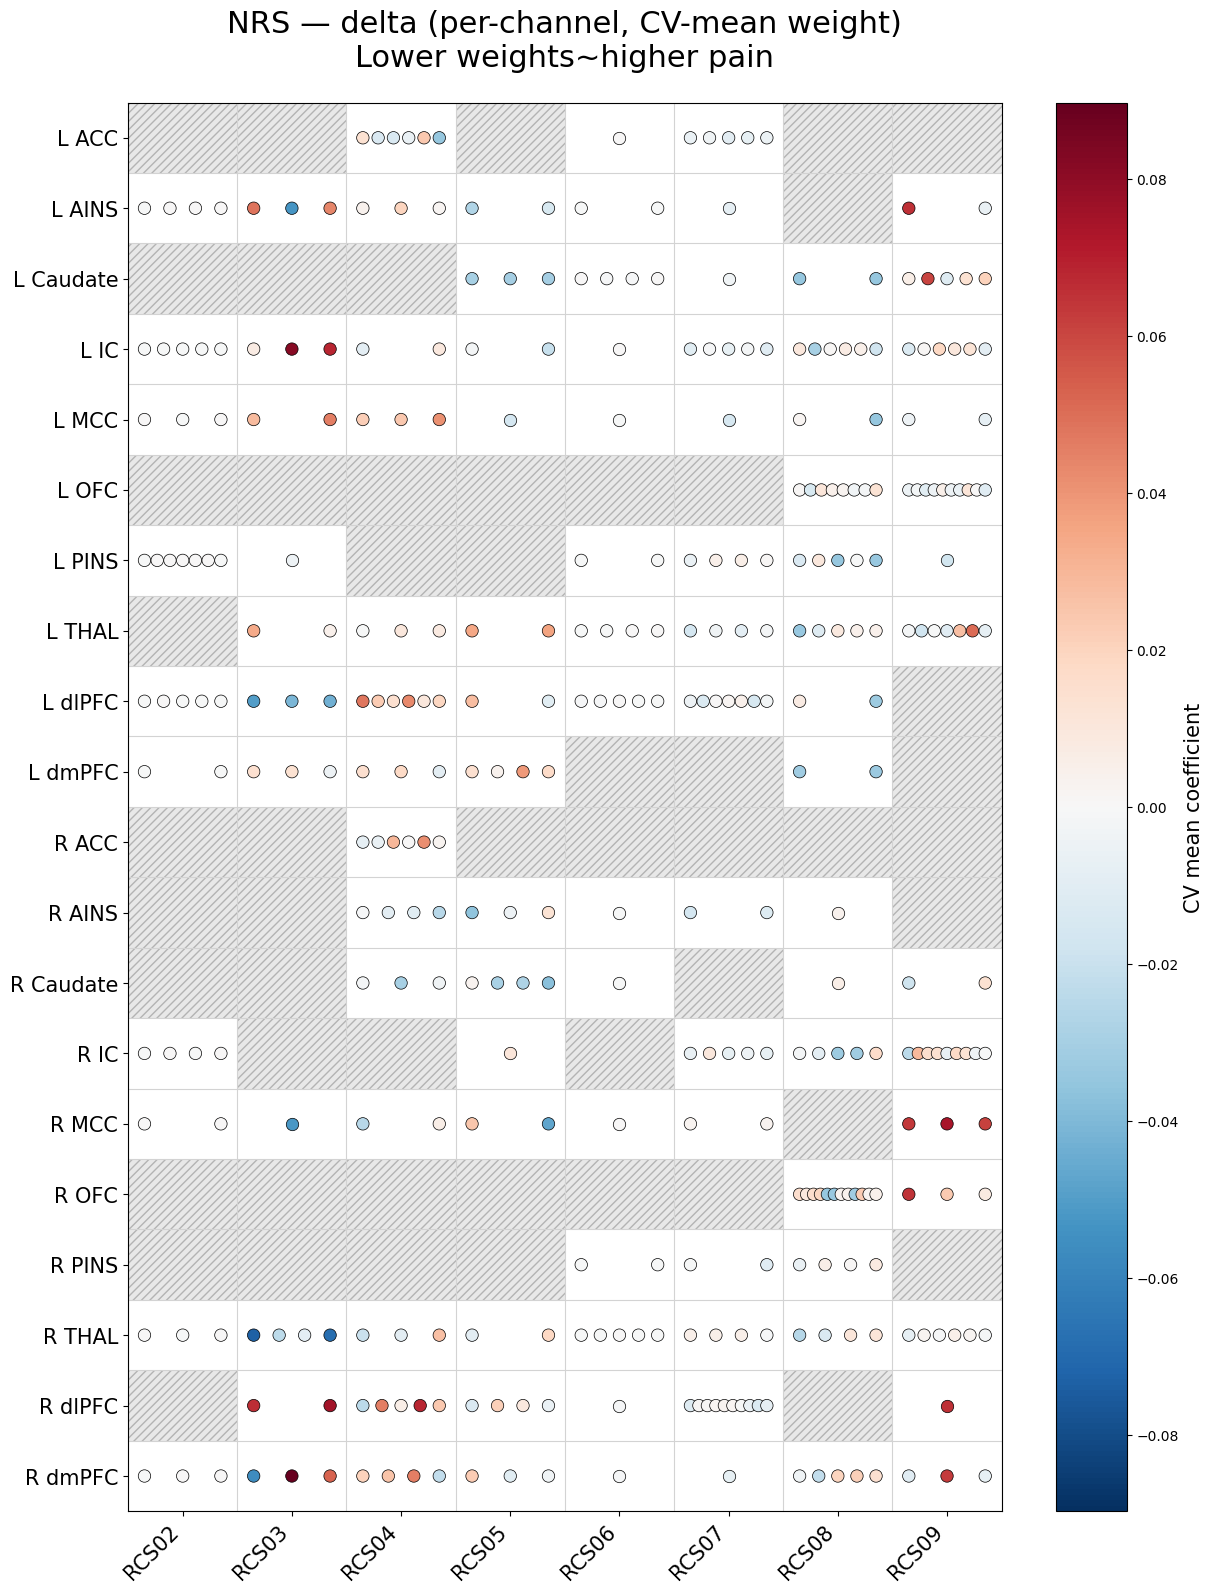

/tmp/ipykernel_877465/1728586565.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['cv_snr_abs'] = abs(metric_df['cv_snr'])


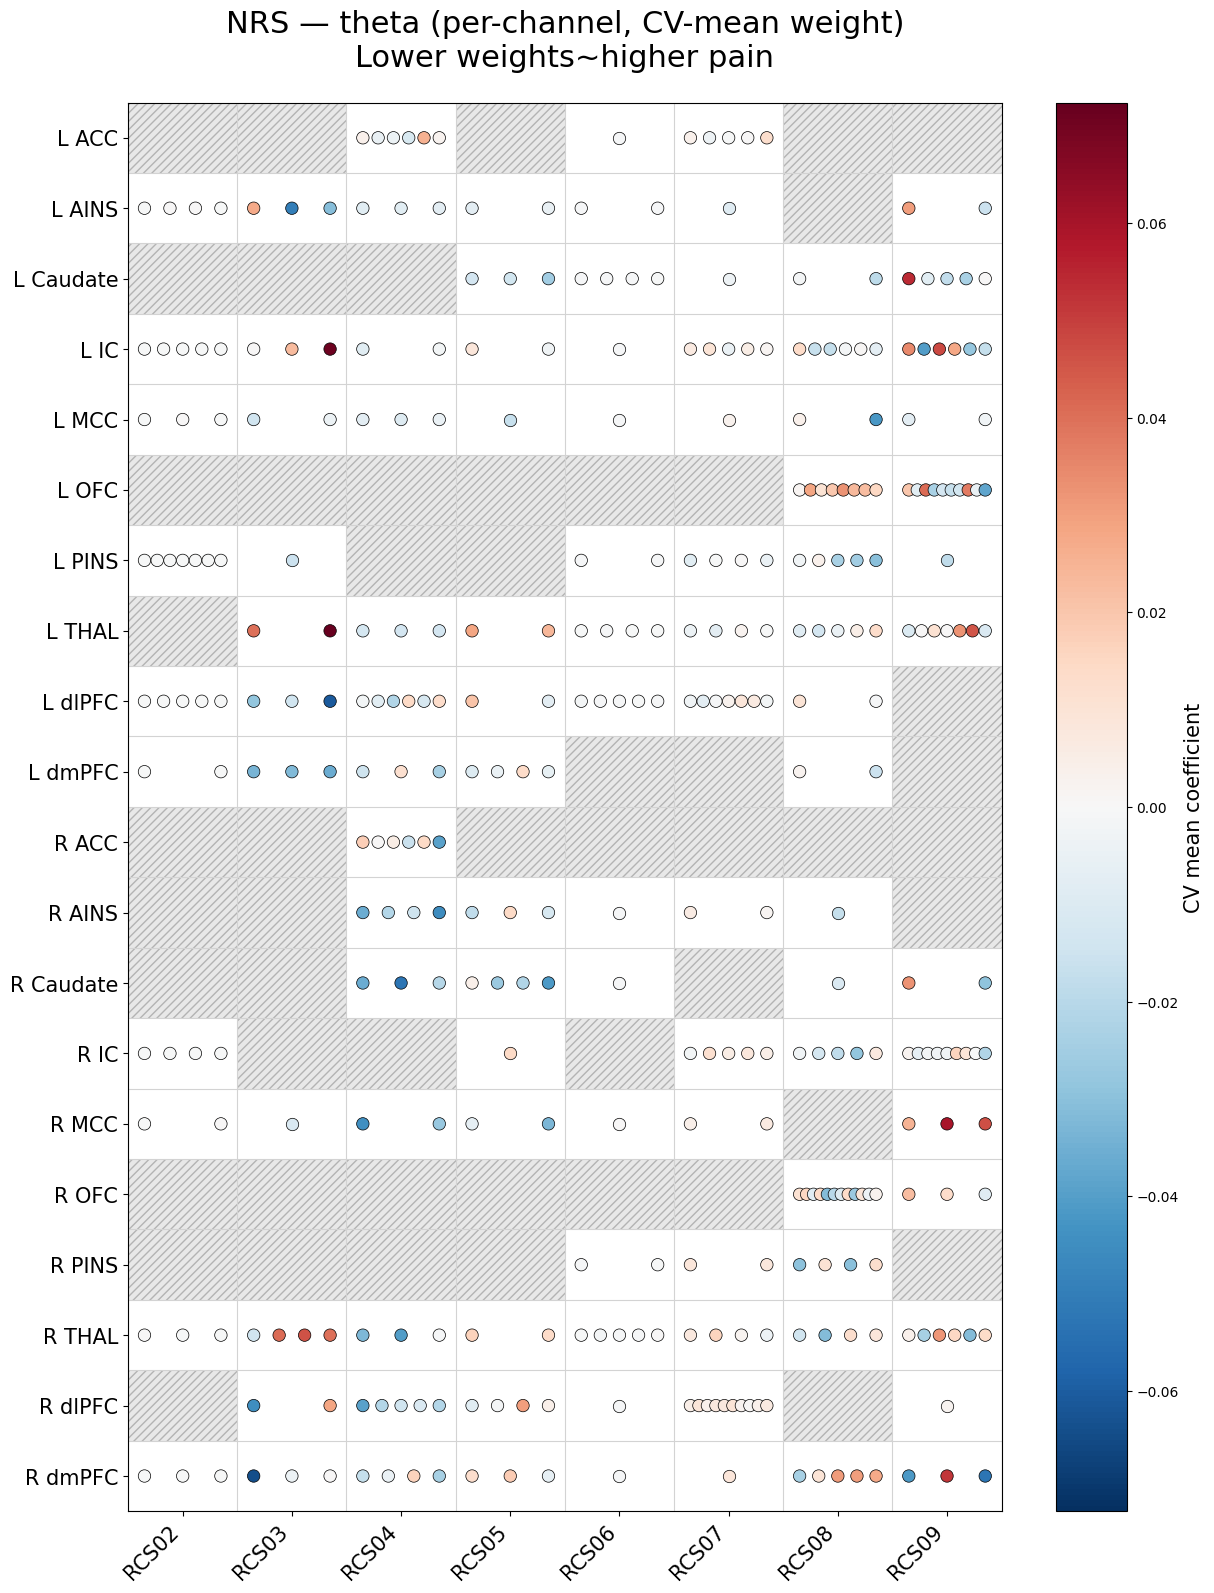

/tmp/ipykernel_877465/1728586565.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['cv_snr_abs'] = abs(metric_df['cv_snr'])


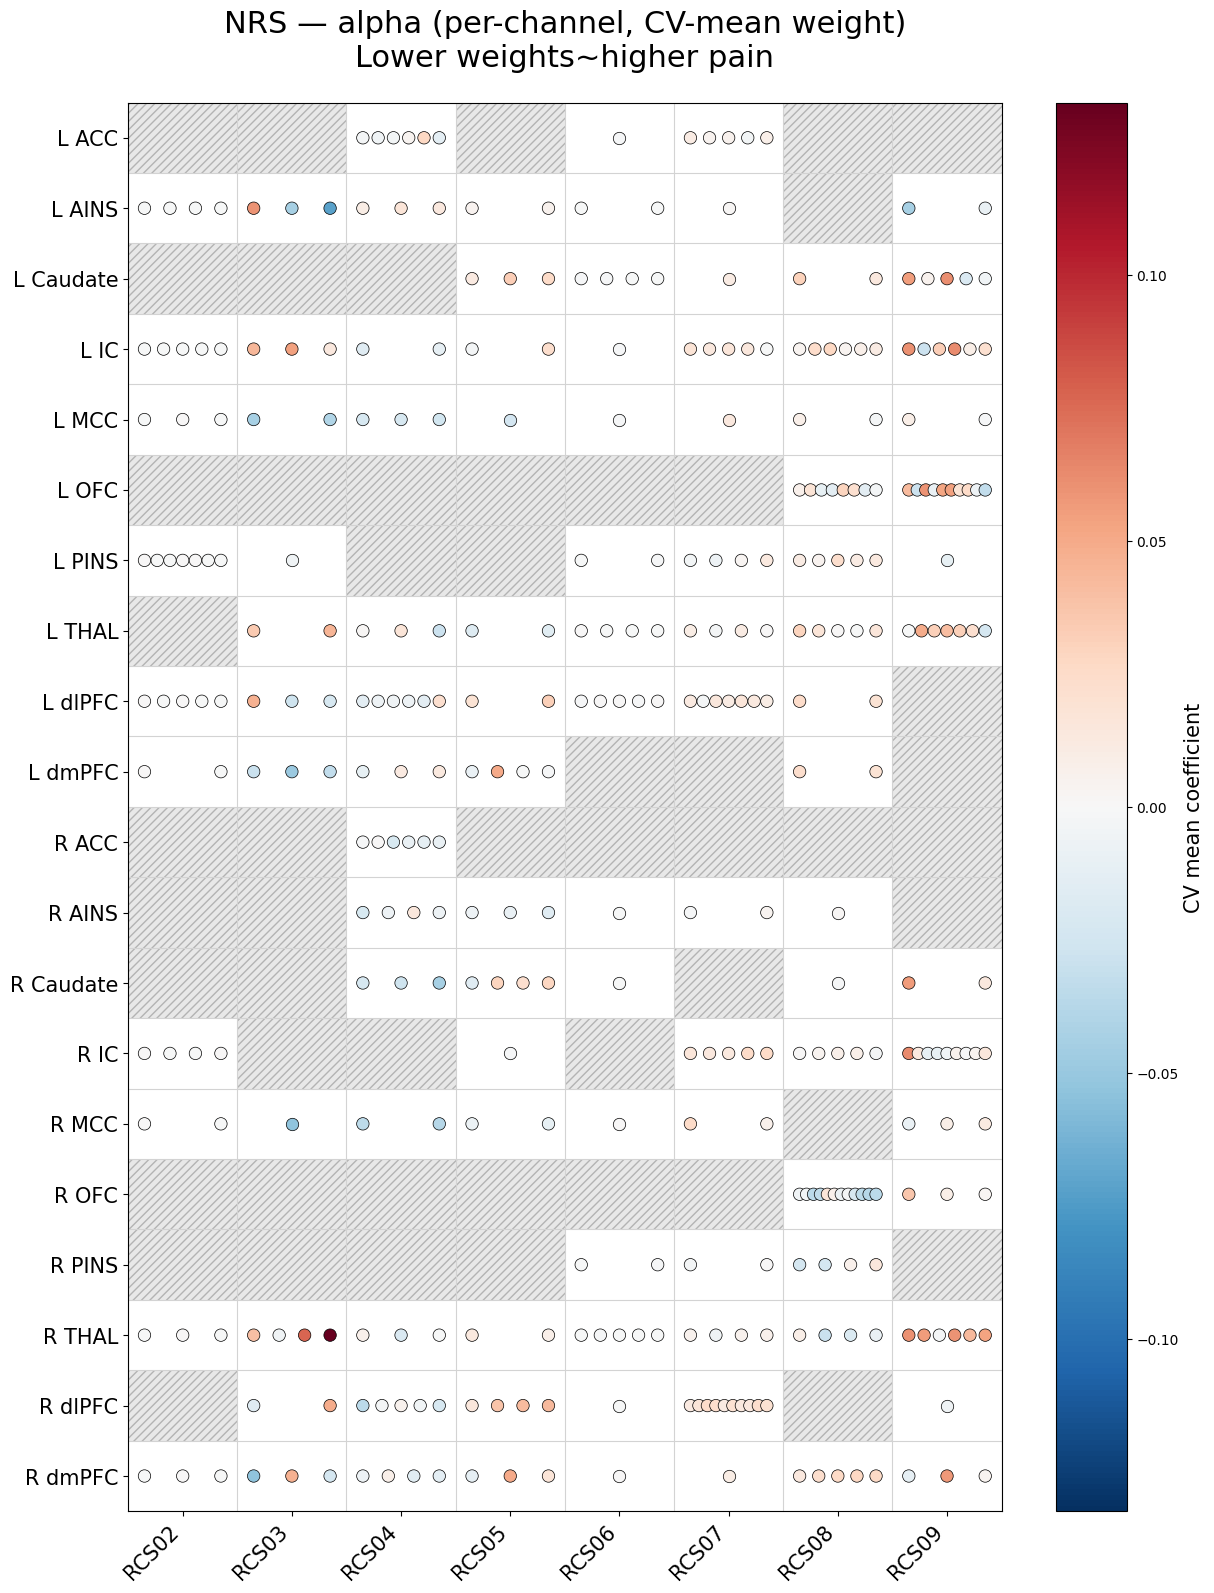

/tmp/ipykernel_877465/1728586565.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['cv_snr_abs'] = abs(metric_df['cv_snr'])


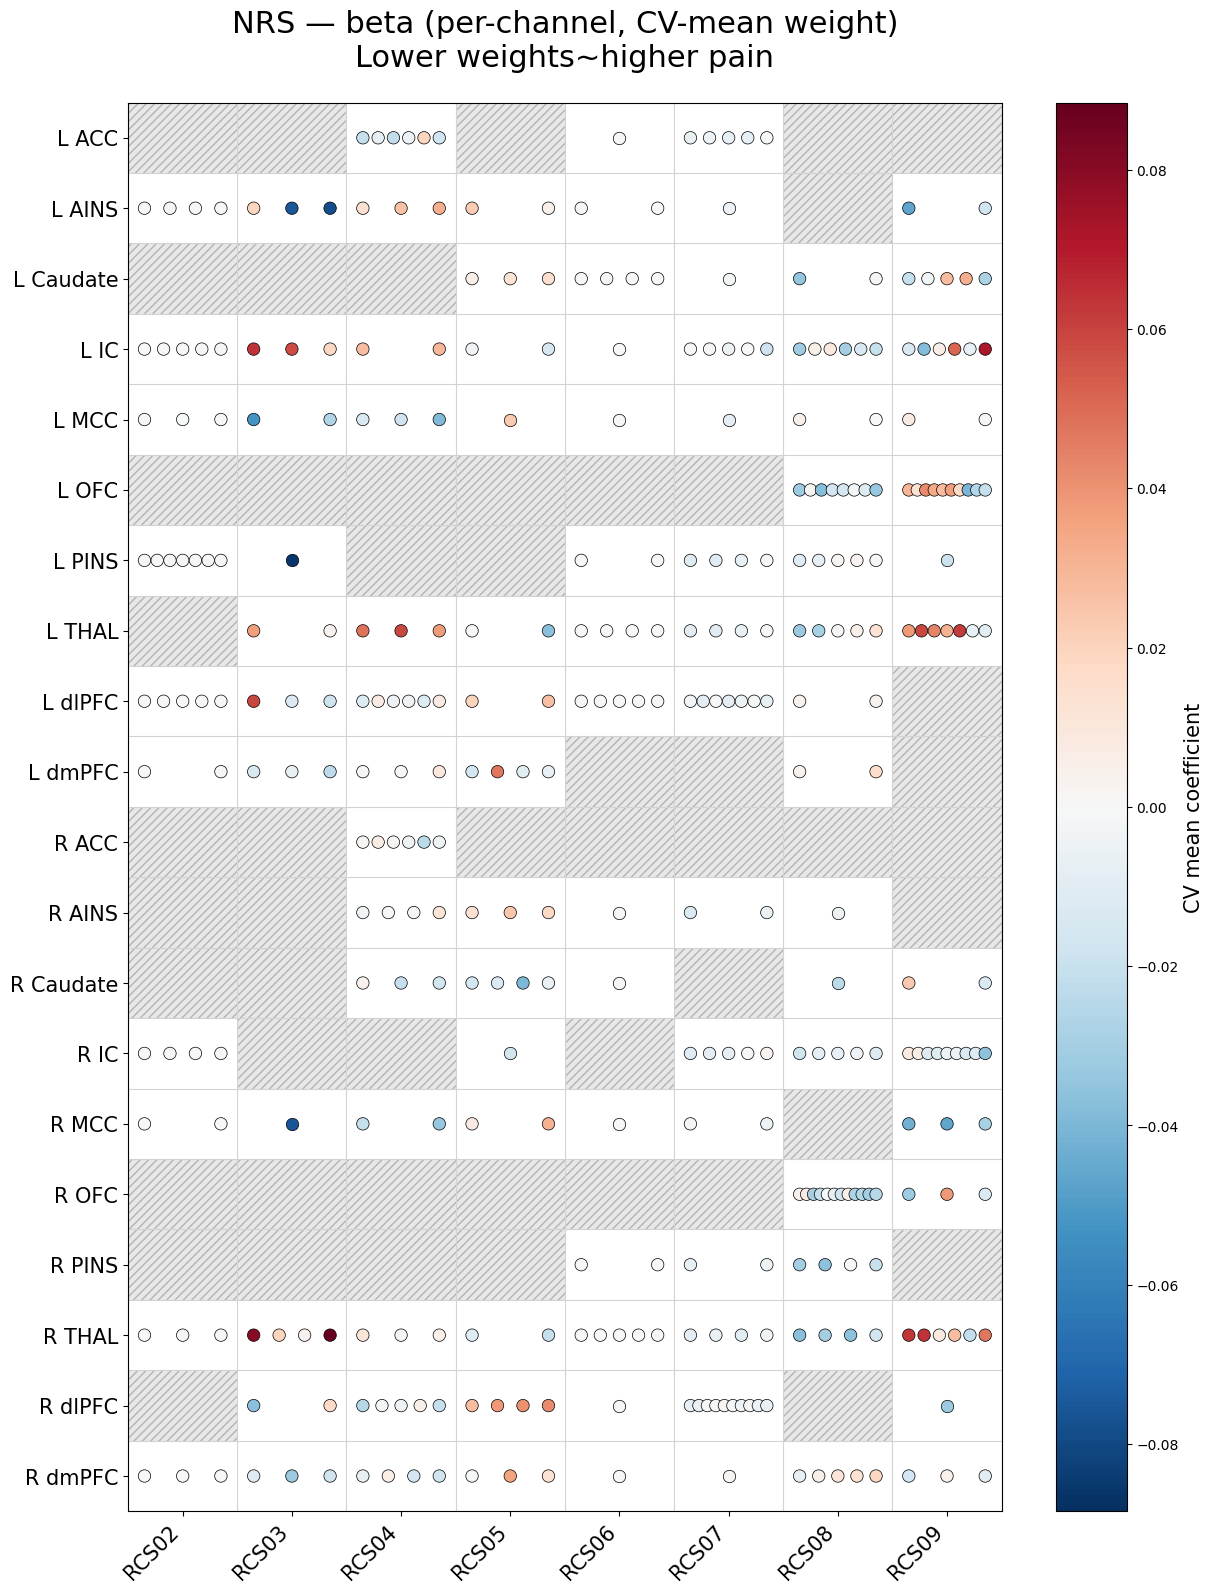

/tmp/ipykernel_877465/1728586565.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metric_df['cv_snr_abs'] = abs(metric_df['cv_snr'])


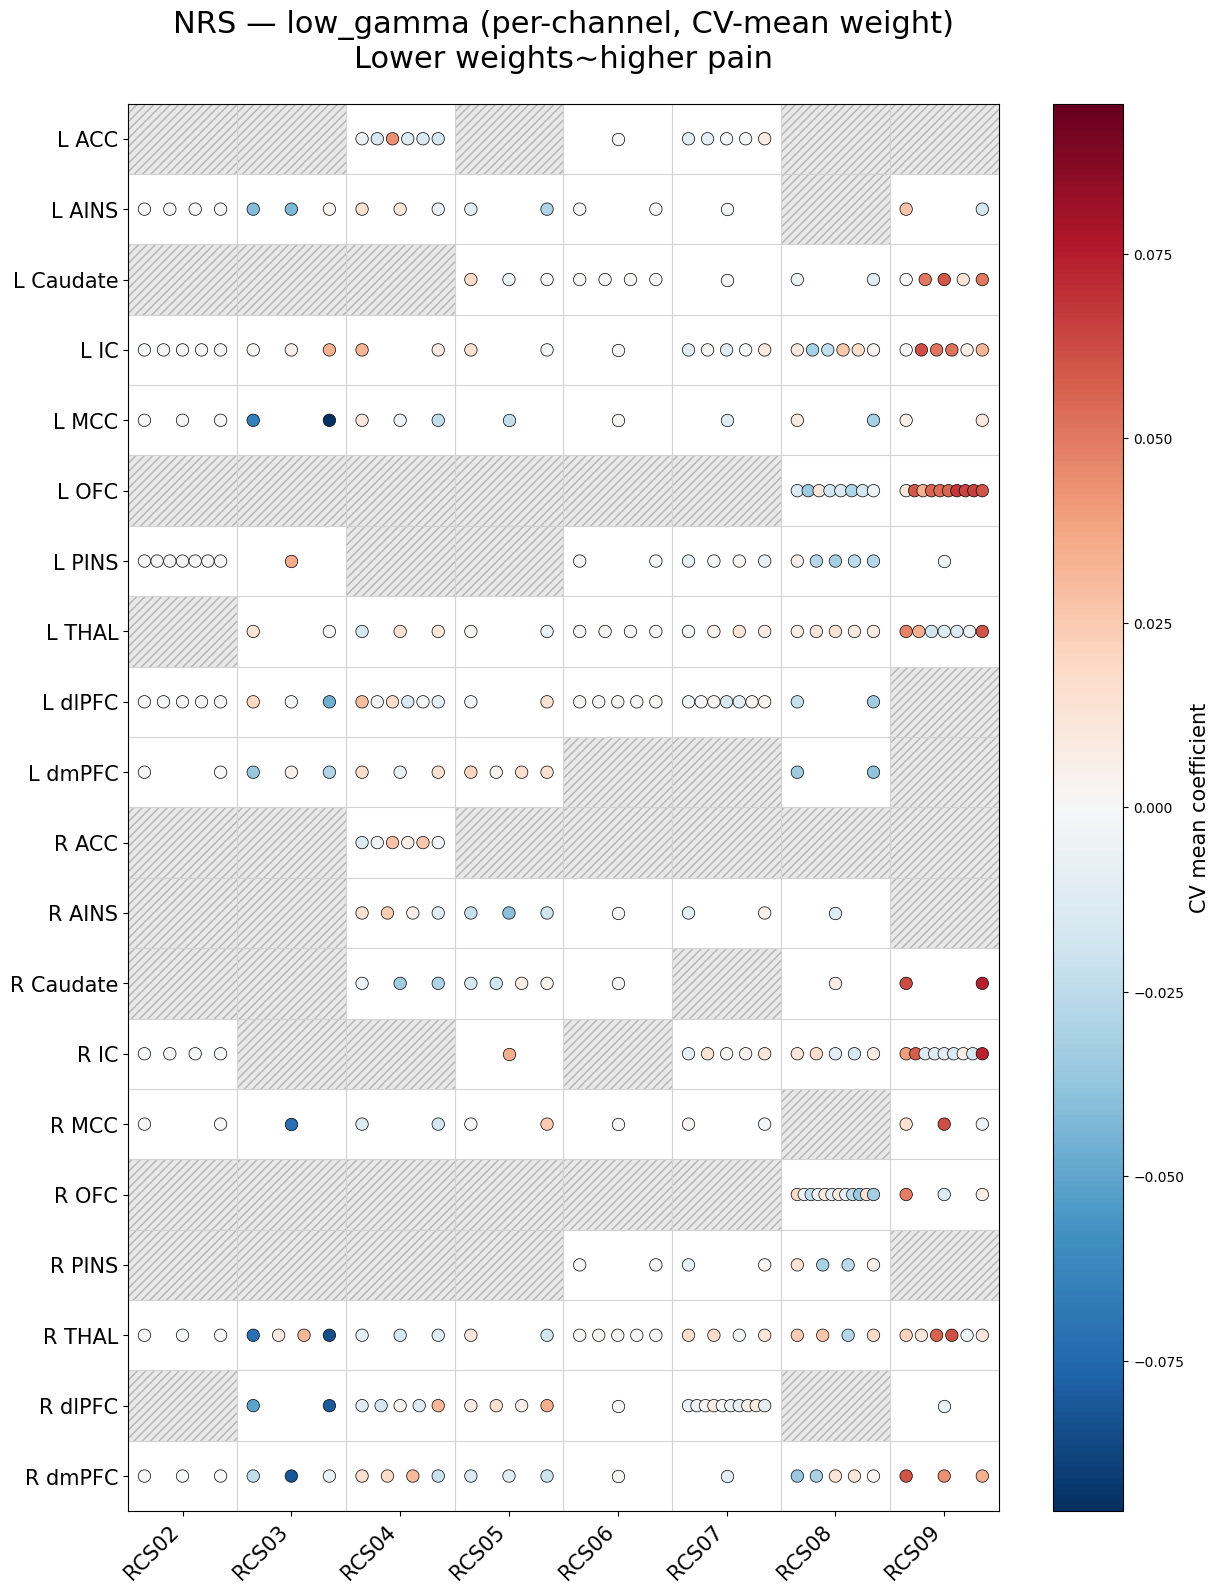

In [27]:
coef_df_all = pd.read_pickle('/home/jiahuang/test-code-hazel/NEW0824_individual_periodic_nrs_coef_stability_allpt.pickle')
# for metric in metrics:
for band in bands:
    # metric_df = coef_df_all[coef_df_all['metric'] == metric]
    metric_df = coef_df_all[coef_df_all['band'] == band]
    metric_df['cv_snr_abs'] = abs(metric_df['cv_snr'])
    if metric_df.empty:
        continue
    # max_temp = metric_df[metric_df['ptID']!='RCS03']
    max_temp = metric_df
    vmax = np.nanmax(np.abs(max_temp['cv_mean_coef'].values))
    # vmax= 3
    rois_order = sorted(metric_df['roi'].unique())
    
    if not np.isfinite(vmax) or vmax == 0:
        continue

    plot_dot_heatmap(
        df=metric_df,
        beta_col='cv_mean_coef',
        # beta_col='cv_snr_abs',
        pval_col=[],
        ptIDs_order=ptIDs_order,
        rois_order=rois_order,
        label='CV mean coefficient',
        # label='CV SNR',
        # title=f'NRS — {metric} (per-channel, CV-SNR (mean weight/s.d.))',
        title=f'NRS — {band} (per-channel, CV-mean weight)\nLower weights~higher pain',
        vmax=vmax,
        alpha=0.05,
        savepath=None,
    )

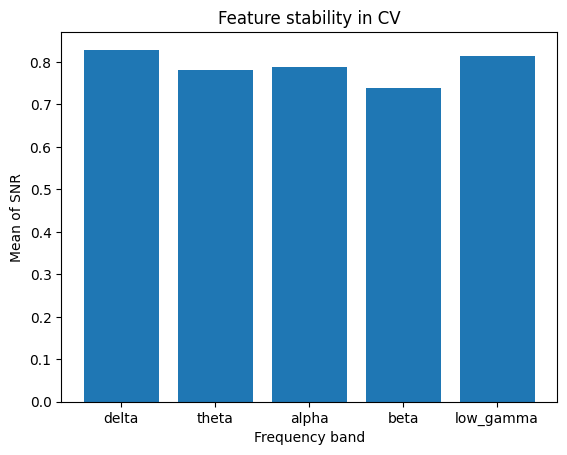

In [20]:
band_order = ['delta', 'theta', 'alpha', 'beta', 'low_gamma']
coef_df_all = pd.read_pickle('/home/jiahuang/test-code-hazel/NEW0824_individual_periodic_nrs_coef_stability_allpt.pickle')
result_temp = coef_df_all.groupby('band')[['cv_mean_coef','cv_snr']].apply(lambda x: x.abs().mean()).reindex(band_order).reset_index()
plt.bar(data=result_temp,x='band',height='cv_snr')
plt.xlabel('Frequency band')
plt.ylabel('Mean of SNR')
plt.title('Feature stability in CV')
plt.show()
# plt.bar(data=coef_df_all.groupby('band')['cv_mean_coef'].apply(lambda x: x.abs().mean()),x='band',y='cv_mean_coef')